# Generate the dataset

In [110]:
import random

In [111]:
# number of blocks ( = number of goals )
N = 3
# block size (in [m])
block_size = 0.2
# whether initial positions are in a tower or scattered around
initial_tower = True

In [112]:
# 1. Generate random order for the goals
idx_goals = [i for i in range(0, N)]
random.shuffle(idx_goals)

# 2. Generate initial order for the blocks by inverting the order of goals
idx_objs = idx_goals[::-1]

# 3. Generate goals
# https://www.generationrobots.com/media/panda-franka-emika-datasheet.pdf
# according to the datasheet, the Franka Panda can reach in an area of 0.855 [m] around itself
max_reach_dist = 0.7 # [m]

# select a random (x,y) position for the goal.
x_goal = random.random() * max_reach_dist
y_goal = random.random() * max_reach_dist

pos_goals = [(x_goal, y_goal, i*block_size) for i in range(0, N)]

# Generate initial positions
if initial_tower:
    x_obj = random.random() * max_reach_dist
    y_obj = random.random() * max_reach_dist

    pos_objects = [(x_obj, y_obj, i*block_size) for i in range(0, N)]
else:
    pos_objects = [(random.random() * max_reach_dist, random.random() * max_reach_dist, i*block_size) for i in range(0, N)]

goals = {}
objects = {}
for i in range(0, N):
    goals[idx_goals[i]] = pos_goals[i]
    objects[idx_objs[i]] = pos_objects[i]

print(f"goals (in desired order of final stacking):\n{goals}")
print(f"initial object positions (in order of stacking):\n{objects}")


goals (in desired order of final stacking):
{0: (0.27530628467162604, 0.4317627291194789, 0.0), 2: (0.27530628467162604, 0.4317627291194789, 0.2), 1: (0.27530628467162604, 0.4317627291194789, 0.4)}
initial object positions (in order of stacking):
{1: (0.537707418074332, 0.6156401841723944, 0.0), 2: (0.537707418074332, 0.6156401841723944, 0.2), 0: (0.537707418074332, 0.6156401841723944, 0.4)}


In [113]:
# Now solve the stacking problem by taking the highest block in the objects tower (last in order)
# and putting it into the lowest available goal (first in order)

tau = []

# build the state vector, ordered nodes with categorical, position and binary features, followed by ordered goals with the same features
def build_state(objects, goals):
    s = []
    for n in range(0, N):
        s.append(1) # objects are all blocks
        for o in objects[n]: s.append(o)
        # s.append(objects[n]) # position of block
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    for n in range(0, N):
        s.append(2) # goals
        # s.append(goals[n]) # position of block
        for o in goals[n]: s.append(o)
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    return s
        
tau.append(build_state(objects, goals))

for n in range(0, N):
    print(f"step #{n}")
    
    o = N-1-n

    print(f"choosing object #{idx_objs[o]} with pos {objects[idx_objs[o]]}")
    print(f"moving object #{idx_objs[o]} to goal{goals[idx_objs[o]]}")

    objects[idx_objs[o]] = goals[idx_objs[o]]
    tau.append([o, o])

    print(f"Updated object positions with goals:")
    print(f"goals:\n{goals}")
    print(f"current objects pos:\n{objects}")
    print("\n")


    tau.append(build_state(objects, goals))

# TODO (?): add the empty action to a complete graph

print(tau)

step #0
choosing object #0 with pos (0.537707418074332, 0.6156401841723944, 0.4)
moving object #0 to goal(0.27530628467162604, 0.4317627291194789, 0.0)
Updated object positions with goals:
goals:
{0: (0.27530628467162604, 0.4317627291194789, 0.0), 2: (0.27530628467162604, 0.4317627291194789, 0.2), 1: (0.27530628467162604, 0.4317627291194789, 0.4)}
current objects pos:
{1: (0.537707418074332, 0.6156401841723944, 0.0), 2: (0.537707418074332, 0.6156401841723944, 0.2), 0: (0.27530628467162604, 0.4317627291194789, 0.0)}


step #1
choosing object #2 with pos (0.537707418074332, 0.6156401841723944, 0.2)
moving object #2 to goal(0.27530628467162604, 0.4317627291194789, 0.2)
Updated object positions with goals:
goals:
{0: (0.27530628467162604, 0.4317627291194789, 0.0), 2: (0.27530628467162604, 0.4317627291194789, 0.2), 1: (0.27530628467162604, 0.4317627291194789, 0.4)}
current objects pos:
{1: (0.537707418074332, 0.6156401841723944, 0.0), 2: (0.27530628467162604, 0.4317627291194789, 0.2), 0: (0

In [114]:
# Alternatevely
# at each step, find the highest block that is not yet in its goal
# and move it to the lowest available goal
# repeat until each blocks is in its goal

# Observation to graph

In [179]:
# Now put the demonstration in graph format, using pytorch geometric

import torch
import torch.nn.functional as F
import torch_geometric
from torch_geometric.utils.convert import to_networkx
import networkx as nx

states = tau[0:-1:2] # exclude the complete graph
actions = tau[1::2]

print(len(states), states)
print(len(states), actions)

# build edges, only once
# graphs are always fully connected, undirected, and with no edge features
edges = []
for i in range(0, N*2):
    for j in range(0, N*2):
        edges.append([i,j])
print(edges)

data_list = []
# build nodes and labels
for n in range(0, N):
    s = states[n]
    a = actions[n]

    # torch_geometric.data.Data is a single graph
    # x is the input graph, as a matrix of dimension [node, node_features]
    # I have N*2 nodes (N blocks, N goals) and 5 features each
    x = torch.reshape(torch.tensor(s), (N*2, -1)) # N*2 considers both goals and blocks
    # y is divided into two vectors, one hot encoded, probabilities for the block and the goal
    y = torch.Tensor.float(F.one_hot(torch.tensor(a), num_classes=N).t())
    y = (y[:, 0].reshape(-1, 1), y[:, 1].reshape(-1, 1))
    G = torch_geometric.data.Data(x=x, edge_index=torch.tensor(edges).t().contiguous(), y=y)

    # save all the graphs into a single data_list for use as a DataLoader later
    data_list.append(G)

print(data_list)

3 [[1, 0.537707418074332, 0.6156401841723944, 0.4, 0, 1, 0.537707418074332, 0.6156401841723944, 0.0, 0, 1, 0.537707418074332, 0.6156401841723944, 0.2, 0, 2, 0.27530628467162604, 0.4317627291194789, 0.0, 0, 2, 0.27530628467162604, 0.4317627291194789, 0.4, 0, 2, 0.27530628467162604, 0.4317627291194789, 0.2, 0], [1, 0.27530628467162604, 0.4317627291194789, 0.0, 1, 1, 0.537707418074332, 0.6156401841723944, 0.0, 0, 1, 0.537707418074332, 0.6156401841723944, 0.2, 0, 2, 0.27530628467162604, 0.4317627291194789, 0.0, 1, 2, 0.27530628467162604, 0.4317627291194789, 0.4, 0, 2, 0.27530628467162604, 0.4317627291194789, 0.2, 0], [1, 0.27530628467162604, 0.4317627291194789, 0.0, 1, 1, 0.537707418074332, 0.6156401841723944, 0.0, 0, 1, 0.27530628467162604, 0.4317627291194789, 0.2, 1, 2, 0.27530628467162604, 0.4317627291194789, 0.0, 1, 2, 0.27530628467162604, 0.4317627291194789, 0.4, 0, 2, 0.27530628467162604, 0.4317627291194789, 0.2, 1]]
3 [[2, 2], [1, 1], [0, 0]]
[[0, 0], [0, 1], [0, 2], [0, 3], [0, 4],

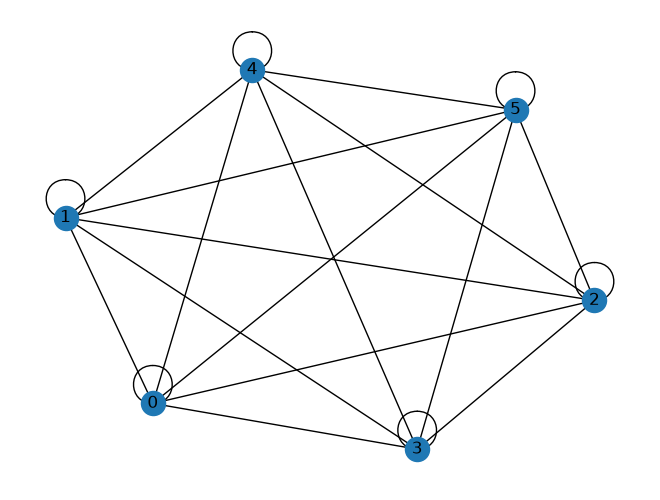

In [180]:
g = torch_geometric.utils.to_networkx(G, to_undirected=True)
nx.draw(g, with_labels=True)

# Build torch_geometric dataset from examples

In [181]:
# https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_dataset.html#frequently-asked-questions
# just create a DataLoader starting from the list of example Data
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=1)

# Build NN

In [185]:
# https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html
# https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html

import torch
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # All policies consist of 3 hidden layers, with 64 hidden units each and ReLU activation.
        # For attention policies, the number of attention heads were set to 1.
        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        print("pre softmax ", x)

        # The output of the GNN policy is K + L dimensional, reshaped into K and L dimensional outputs
        objects = x[:N, :]
        goals = x[N:, :]

        print("slice")
        print()
        print(objects, goals)

        # and is then passed through a softmax function to generate a K-dimensional cateagorial distribution
        # depicting the picking probabilities of objects. 
        # The object with the highest predicted probability is the output of the GNN
        return (F.softmax(objects, dim=1), F.softmax(goals, dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
model.train()

running_loss = 0.
last_loss = 0.

# index and do some intra-epoch reporting
for i, data in enumerate(loader):
    # Every data instance is an input + label pair
    print(data)

    # Zero your gradients for every batch!
    optimizer.zero_grad()

    # Make predictions for this batch
    out = model(data)

    print("labels")
    print(data.y)
    print("prediction")
    print(out)

    # Compute the loss and its gradients
    loss = F.cross_entropy(out[0], data.y[0]) +  F.cross_entropy(out[1], data.y[1])
    loss.backward()

    # Adjust learning weights
    optimizer.step()

    # Gather data and report
    running_loss += loss.item()
    if i % 1000 == 999:
        last_loss = running_loss / 1000 # loss per batch
        print(f'  batch {i + 1} loss: {last_loss}')
        tb_x = epoch_index * len(training_loader) + i + 1
        tb_writer.add_scalar('Loss/train', last_loss, tb_x)
        running_loss = 0.

DataBatch(x=[6, 5], edge_index=[2, 36], y=[2], batch=[6], ptr=[2])
pre softmax  tensor([[-0.0369],
        [-0.0369],
        [-0.0369],
        [-0.0369],
        [-0.0369],
        [-0.0369]], grad_fn=<AddBackward0>)
slice

tensor([[-0.0369],
        [-0.0369],
        [-0.0369]], grad_fn=<SliceBackward0>) tensor([[-0.0369],
        [-0.0369],
        [-0.0369]], grad_fn=<SliceBackward0>)
labels
[tensor([[0.],
        [0.],
        [1.]]), tensor([[0.],
        [0.],
        [1.]])]
prediction
(tensor([[1.],
        [1.],
        [1.]], grad_fn=<SoftmaxBackward0>), tensor([[1.],
        [1.],
        [1.]], grad_fn=<SoftmaxBackward0>))
DataBatch(x=[6, 5], edge_index=[2, 36], y=[2], batch=[6], ptr=[2])
pre softmax  tensor([[-0.0349],
        [-0.0349],
        [-0.0349],
        [-0.0349],
        [-0.0349],
        [-0.0349]], grad_fn=<AddBackward0>)
slice

tensor([[-0.0349],
        [-0.0349],
        [-0.0349]], grad_fn=<SliceBackward0>) tensor([[-0.0349],
        [-0.0349],
      